# Exploratory Data Analysis (EDA)
## Combined Cycle Power Plant

EDA dilakukan untuk memahami karakteristik dataset sebelum proses
cleaning, preprocessing, dan pembangunan model Machine Learning.

Analisis meliputi:
1. Statistik deskriptif
2. Distribusi variabel
3. Skewness
4. Deteksi awal kandidat outlier
5. Hubungan setiap fitur dengan PE
6. Korelasi antarvariabel

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "../data/raw/Folds5x2_pp.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


In [19]:
skewness = df.skew(numeric_only=True)

pd.DataFrame({
    "skewness": skewness
})

,skewness
AT,-0.136393
V,0.198521
AP,0.265445
RH,-0.431839
PE,0.306509


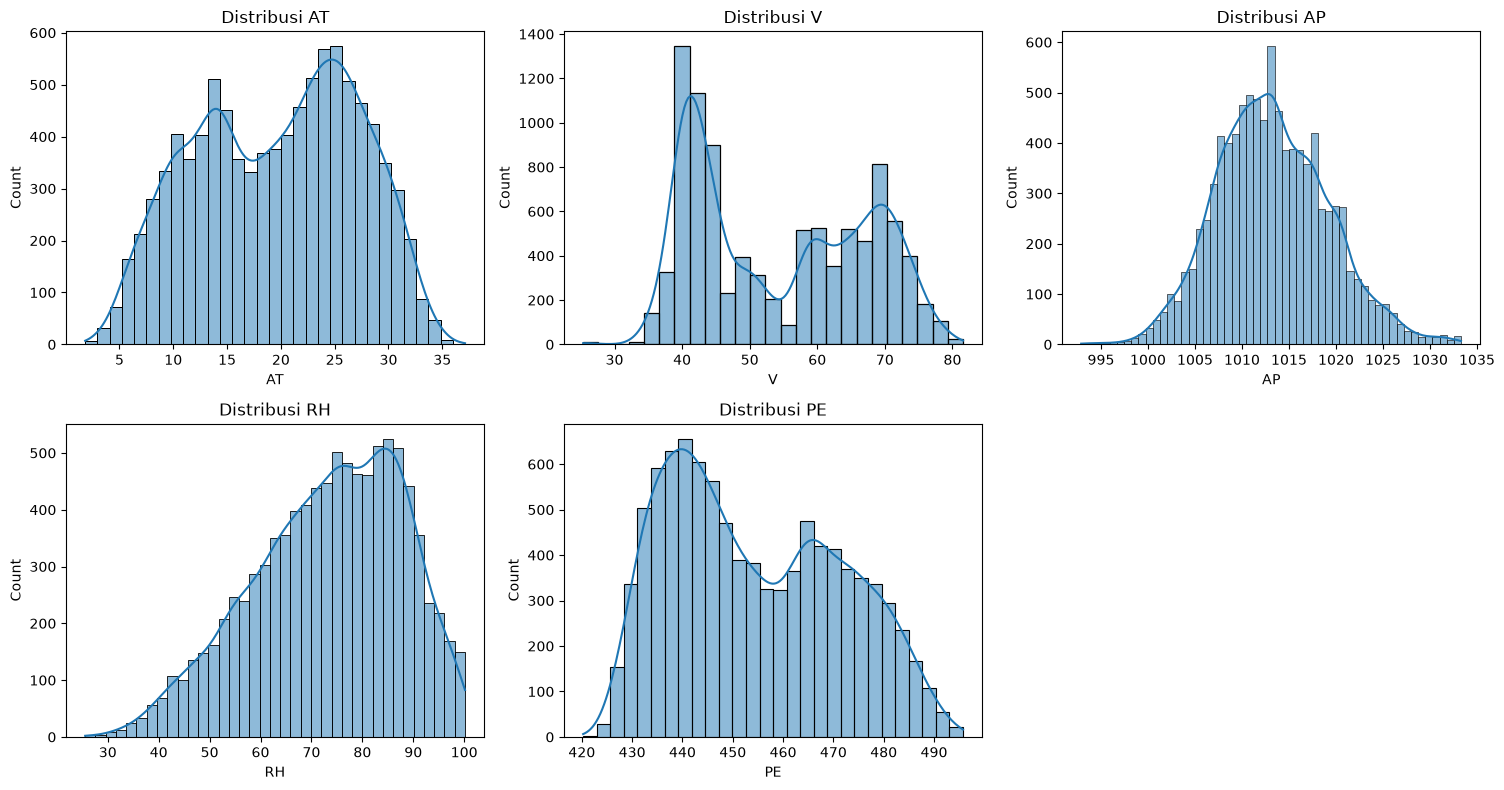

In [20]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

columns = ["AT", "V", "AP", "RH", "PE"]

for ax, column in zip(axes.flat, columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribusi {column}")

axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()

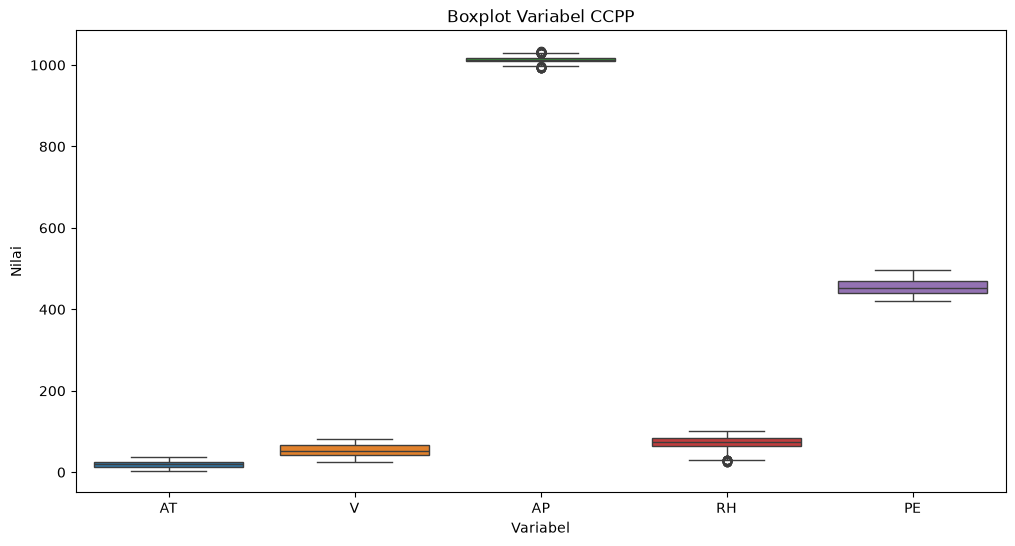

In [21]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df)

plt.title("Boxplot Variabel CCPP")
plt.xlabel("Variabel")
plt.ylabel("Nilai")

plt.show()

In [22]:
outlier_summary = {}

for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

pd.DataFrame.from_dict(
    outlier_summary,
    orient="index",
    columns=["Jumlah kandidat outlier"]
)

,Jumlah kandidat outlier
AT,0
V,0
AP,88
RH,12
PE,0


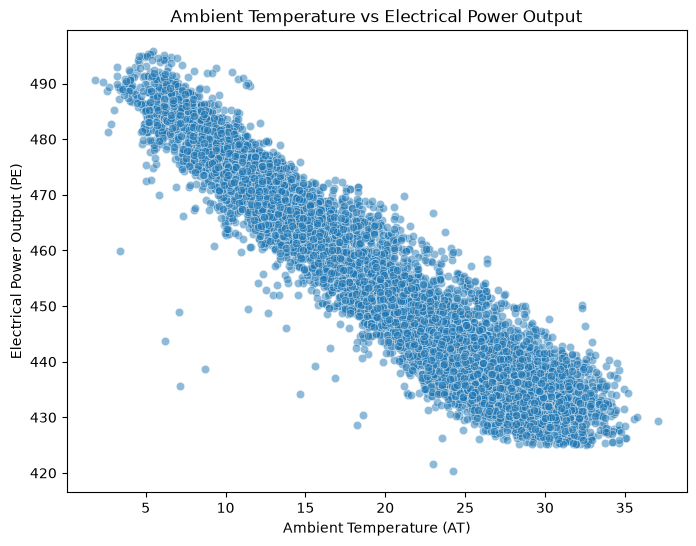

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="AT",
    y="PE",
    alpha=0.5
)

plt.title("Ambient Temperature vs Electrical Power Output")
plt.xlabel("Ambient Temperature (AT)")
plt.ylabel("Electrical Power Output (PE)")

plt.show()

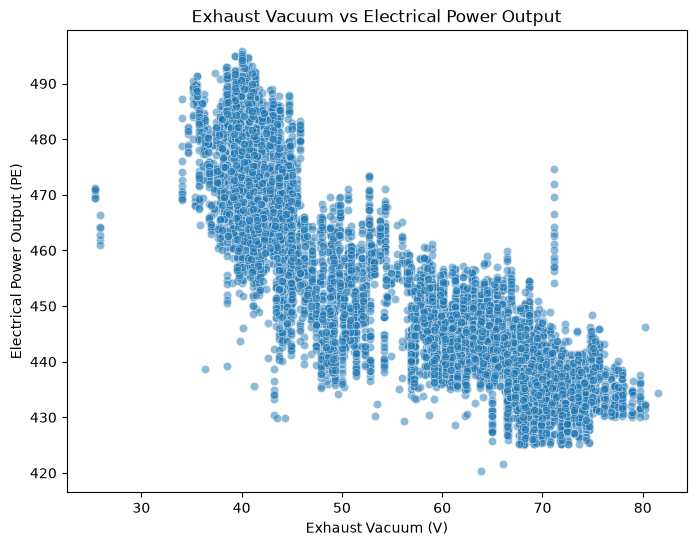

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="V",
    y="PE",
    alpha=0.5
)

plt.title("Exhaust Vacuum vs Electrical Power Output")
plt.xlabel("Exhaust Vacuum (V)")
plt.ylabel("Electrical Power Output (PE)")

plt.show()

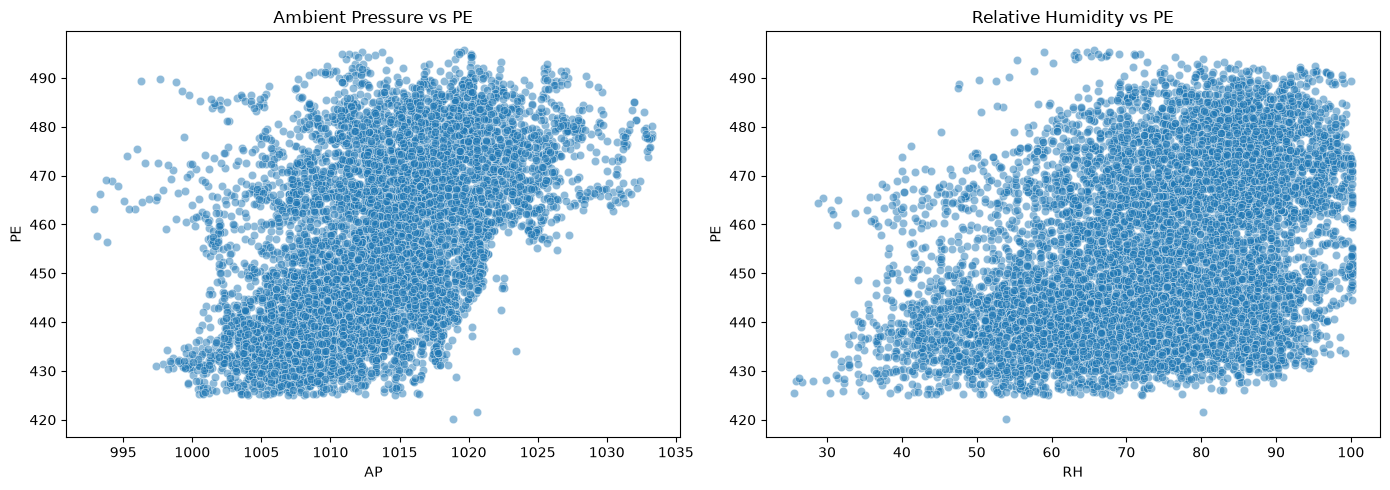

In [25]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

sns.scatterplot(
    data=df,
    x="AP",
    y="PE",
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Ambient Pressure vs PE")
axes[0].set_xlabel("AP")
axes[0].set_ylabel("PE")

sns.scatterplot(
    data=df,
    x="RH",
    y="PE",
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("Relative Humidity vs PE")
axes[1].set_xlabel("RH")
axes[1].set_ylabel("PE")

plt.tight_layout()
plt.show()

In [26]:
correlation_matrix = df.corr()

correlation_matrix

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


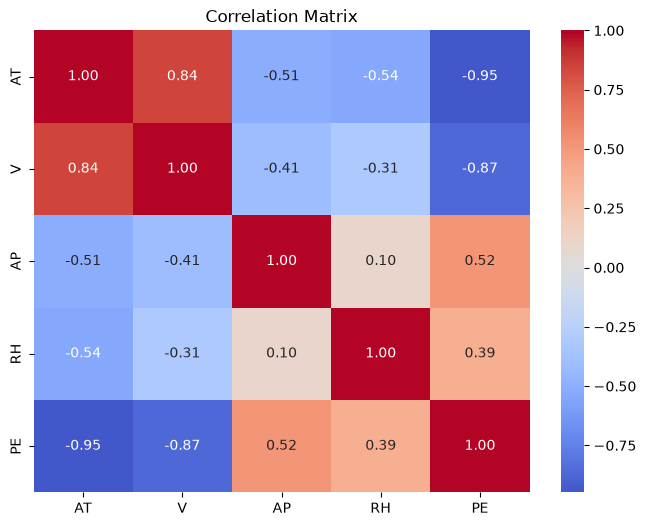

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [28]:
target_correlation = (
    df.corr()["PE"]
    .drop("PE")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlation

AT   -0.948128
V    -0.869780
AP    0.518429
RH    0.389794
Name: PE, dtype: float64

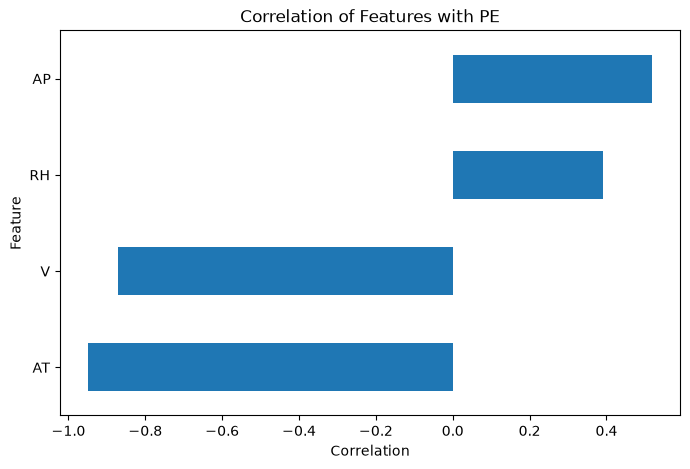

In [29]:
plt.figure(figsize=(8, 5))

target_correlation.sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Features with PE")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

## Kesimpulan EDA

Berdasarkan hasil eksplorasi data, diperoleh beberapa temuan:

1. Dataset terdiri dari 9.568 observasi dengan lima variabel numerik.

2. Distribusi AT, V, dan PE menunjukkan pola multimodal, yang
   mengindikasikan adanya beberapa kelompok kondisi operasi dalam data.

3. Boxplot menunjukkan kandidat outlier secara statistik terutama pada
   variabel AP dan RH. Kandidat tersebut tidak langsung dianggap sebagai
   data invalid.

4. Ambient Temperature (AT) memiliki hubungan negatif yang sangat kuat
   dengan Electrical Power Output (PE), dengan korelasi sekitar -0.95.

5. Exhaust Vacuum (V) juga memiliki hubungan negatif yang kuat dengan PE,
   dengan korelasi sekitar -0.87.

6. Ambient Pressure (AP) memiliki hubungan positif sedang dengan PE,
   sedangkan Relative Humidity (RH) memiliki hubungan positif yang lebih
   lemah.

7. AT dan V memiliki korelasi yang cukup tinggi satu sama lain sehingga
   hubungan antarfitur perlu diperhatikan pada tahap pemodelan.

Hasil EDA digunakan sebagai dasar untuk menentukan strategi cleaning,
preprocessing, dan feature engineering pada tahap berikutnya.